# Discriminative Neuron Analysis

Analyze discriminative neurons in BERT for AI vs Human text classification.

## Structure
- Section A: Neuron Discovery & Distribution
- Section B: Activation Pattern Analysis
- Section C: Statistical Validation

## Outputs
- Table 1: Summary statistics
- Figure 1: Layer-wise distribution
- Figure 2: Top-10 neuron activation boxplots
- Figure 3: Mean activation scatter

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Statistical parameters
ALPHA = 0.001  # Significance level for Mann-Whitney U test
AUC_THRESHOLD_LOW = 0.3  # Human-preferring threshold
AUC_THRESHOLD_HIGH = 0.7  # AI-preferring threshold

# --- Change this to point at whichever activation results you want to analyse ---
# RESULTS_PATH = Path('../results/activations')                      # original dataset
RESULTS_PATH = Path('../results/activations_raid_gpt4')     # RAID GPT-4 vs human

FIGURES_PATH = Path('../results/figures')
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
ALL_LAYERS = list(range(1, 13))
NEURONS_PER_LAYER = 768
TOTAL_NEURONS = NEURONS_PER_LAYER * len(ALL_LAYERS)

In [22]:
# Load all neuron statistics
all_stats = []
for layer in ALL_LAYERS:
    df = pd.read_csv(RESULTS_PATH / f'layer_{layer}_neuron_stats.csv')
    df['layer'] = layer
    all_stats.append(df)

neurons_df = pd.concat(all_stats, ignore_index=True)
disc_df = neurons_df[neurons_df['discriminative']].copy()

labels = np.load(RESULTS_PATH / 'labels.npy')
ai_mask = labels == 1
human_mask = labels == 0

print(f'Loaded {len(neurons_df)} neurons from {len(ALL_LAYERS)} layers')
print(f'Discriminative neurons: {len(disc_df)}')
print(f'Samples: {len(labels)} (AI: {ai_mask.sum()}, Human: {human_mask.sum()})')

Loaded 9216 neurons from 12 layers
Discriminative neurons: 1255
Samples: 1000 (AI: 500, Human: 500)


In [23]:
# Calculate Cohen's d
disc_df['mean_diff'] = disc_df['ai_median'] - disc_df['human_median']
disc_df['ai_iqr'] = disc_df['ai_q75'] - disc_df['ai_q25']
disc_df['human_iqr'] = disc_df['human_q75'] - disc_df['human_q25']
pooled_iqr = (disc_df['ai_iqr'] + disc_df['human_iqr']) / 2 / 1.35
disc_df['cohens_d'] = disc_df['mean_diff'] / pooled_iqr.replace(0, 1e-10)

# Section A: Neuron Discovery & Distribution

In [24]:
# Table 1: Summary Statistics
n_total = len(neurons_df)
n_discriminative = len(disc_df)
n_ai_pref = (disc_df['auc'] > AUC_THRESHOLD_HIGH).sum()
n_human_pref = (disc_df['auc'] < AUC_THRESHOLD_LOW).sum()

layer_counts = disc_df.groupby('layer').size()
peak_layer = layer_counts.idxmax()
peak_count = layer_counts.max()

early = disc_df[disc_df['layer'] <= 4]
middle = disc_df[(disc_df['layer'] >= 5) & (disc_df['layer'] <= 8)]
late = disc_df[disc_df['layer'] >= 9]

print('='*60)
print('TABLE 1: DISCRIMINATIVE NEURON SUMMARY')
print('='*60)
print(f"{'Metric':<40} {'Value':>15}")
print('-'*60)
print(f"{'Total BERT neurons analyzed':<40} {n_total:>15,}")
print(f"{'Discriminative neurons identified':<40} {n_discriminative:>15,}")
print(f"{'Percentage of total':<40} {n_discriminative/n_total*100:>14.1f}%")
print('-'*60)
print(f"{'AI-preferring (AUC > ' + str(AUC_THRESHOLD_HIGH) + ')':<40} {n_ai_pref:>15,}")
print(f"{'Human-preferring (AUC < ' + str(AUC_THRESHOLD_LOW) + ')':<40} {n_human_pref:>15,}")
print(f"{'AI:Human ratio':<40} {n_ai_pref/max(n_human_pref,1):>14.2f}:1")
print(f"{'Mean AUC deviation from 0.5':<40} {disc_df['auc_deviation'].mean():>15.3f}")
print('-'*60)
print(f"{'Early layers (1-4)':<40} {len(early):>15,}")
print(f"{'Middle layers (5-8)':<40} {len(middle):>15,}")
print(f"{'Late layers (9-12)':<40} {len(late):>15,}")
print(f"{'Peak layer':<40} {'Layer ' + str(peak_layer):>15}")
print('='*60)

TABLE 1: DISCRIMINATIVE NEURON SUMMARY
Metric                                             Value
------------------------------------------------------------
Total BERT neurons analyzed                        9,216
Discriminative neurons identified                  1,255
Percentage of total                                13.6%
------------------------------------------------------------
AI-preferring (AUC > 0.7)                            645
Human-preferring (AUC < 0.3)                         610
AI:Human ratio                                     1.06:1
Mean AUC deviation from 0.5                        0.245
------------------------------------------------------------
Early layers (1-4)                                   391
Middle layers (5-8)                                  393
Late layers (9-12)                                   471
Peak layer                                       Layer 8


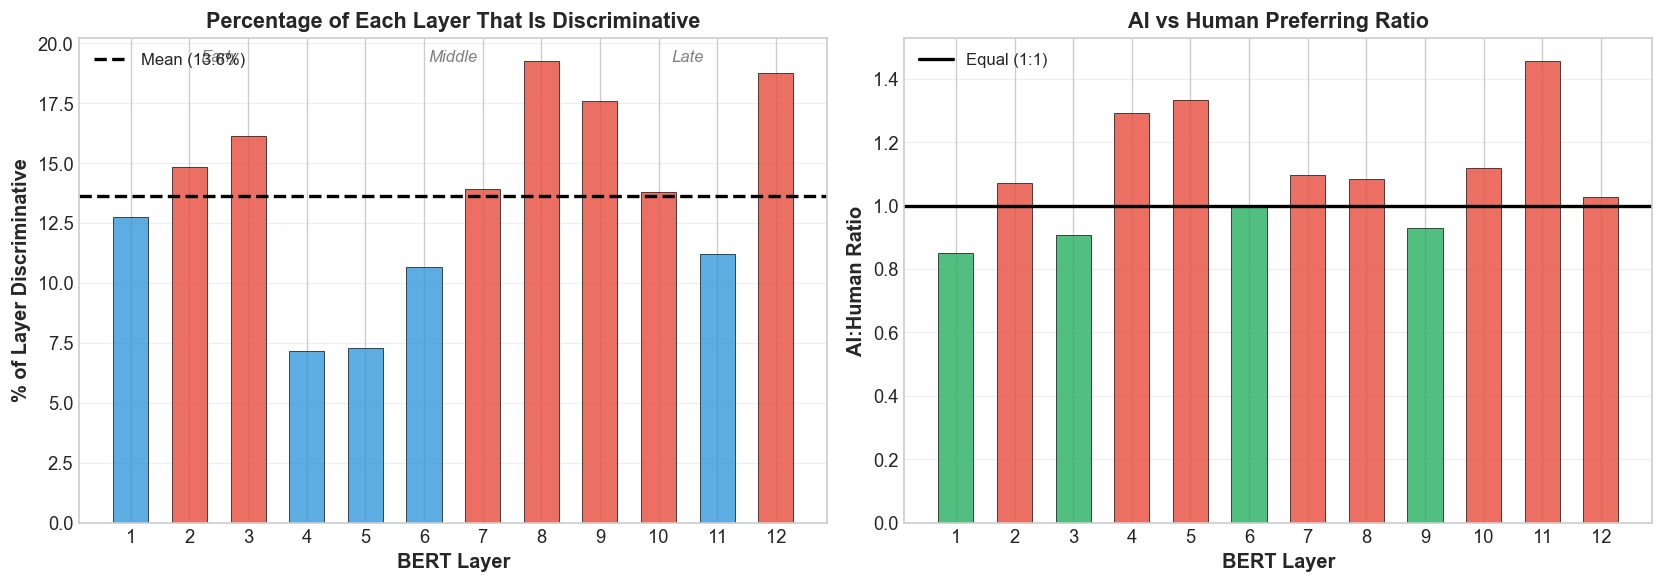

Saved: ..\results\figures\figure1_layer_distribution.png


In [25]:
# Figure 1: Layer-wise Distribution
layer_stats = []
for layer in ALL_LAYERS:
    lyr_neurons = neurons_df[neurons_df['layer'] == layer]
    lyr_disc = lyr_neurons[lyr_neurons['discriminative']]
    layer_stats.append({
        'layer': layer,
        'total': len(lyr_neurons),
        'discriminative': len(lyr_disc),
        'pct_discriminative': len(lyr_disc) / len(lyr_neurons) * 100,
        'ai_preferring': (lyr_disc['auc'] > AUC_THRESHOLD_HIGH).sum(),
        'human_preferring': (lyr_disc['auc'] < AUC_THRESHOLD_LOW).sum()
    })
layer_df = pd.DataFrame(layer_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = layer_df['layer']
width = 0.6

# Plot 1: Percentage discriminative per layer
ax = axes[0]
mean_pct = layer_df['pct_discriminative'].mean()
colors = ['#e74c3c' if pct >= mean_pct else '#3498db' for pct in layer_df['pct_discriminative']]
ax.bar(x, layer_df['pct_discriminative'], width, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(mean_pct, color='black', linestyle='--', linewidth=2, label=f'Mean ({mean_pct:.1f}%)')
ax.set_xlabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('% of Layer Discriminative', fontsize=12, fontweight='bold')
ax.set_title('Percentage of Each Layer That Is Discriminative', fontsize=13, fontweight='bold')
ax.set_xticks(ALL_LAYERS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add layer group annotations
ylim = ax.get_ylim()[1]
ax.text(2.5, ylim*0.95, 'Early', ha='center', fontsize=10, fontstyle='italic', color='gray')
ax.text(6.5, ylim*0.95, 'Middle', ha='center', fontsize=10, fontstyle='italic', color='gray')
ax.text(10.5, ylim*0.95, 'Late', ha='center', fontsize=10, fontstyle='italic', color='gray')

# Plot 2: AI vs Human ratio per layer
ax = axes[1]
ratio = layer_df['ai_preferring'] / layer_df['human_preferring'].replace(0, 1)
colors = ['#e74c3c' if r > 1 else '#27ae60' for r in ratio]
ax.bar(x, ratio, width, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(1, color='black', linestyle='-', linewidth=2, label='Equal (1:1)')
ax.set_xlabel('BERT Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('AI:Human Ratio', fontsize=12, fontweight='bold')
ax.set_title('AI vs Human Preferring Ratio', fontsize=13, fontweight='bold')
ax.set_xticks(ALL_LAYERS)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure1_layer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure1_layer_distribution.png"}')

In [26]:
# Top-K identification
top20 = disc_df.nlargest(20, 'auc_deviation')[['layer', 'neuron_idx', 'auc', 'cohens_d', 'p_value', 'direction']]
top20['rank'] = range(1, 21)
top20 = top20[['rank', 'layer', 'neuron_idx', 'auc', 'cohens_d', 'p_value', 'direction']]

print('TOP-20 DISCRIMINATIVE NEURONS')
print('='*85)
print(top20.to_string(index=False))
print('='*85)
print(f"Top-20 are from layers: {sorted(top20['layer'].unique())}")
print(f"Mean AUC deviation from 0.5: {disc_df.nlargest(20, 'auc_deviation')['auc_deviation'].mean():.3f}")
print(f"Mean |Cohen's d|: {top20['cohens_d'].abs().mean():.3f}")
print(f"All top-20 have |Cohen's d| > 1.0: {(top20['cohens_d'].abs() > 1.0).all()}")

TOP-20 DISCRIMINATIVE NEURONS
 rank  layer  neuron_idx      auc  cohens_d  p_value        direction
    1     12         141 0.107924 -1.818280      0.0 Human-preferring
    2      8         756 0.889484  2.000739      0.0    AI-preferring
    3      9         756 0.877680  1.835545      0.0    AI-preferring
    4      8         509 0.877132  1.935903      0.0    AI-preferring
    5      8         585 0.124484 -1.789282      0.0 Human-preferring
    6      7         509 0.873064  1.571181      0.0    AI-preferring
    7      8         716 0.866112  1.486217      0.0    AI-preferring
    8     12         446 0.136576 -1.493078      0.0 Human-preferring
    9      9          81 0.860584  1.627845      0.0    AI-preferring
   10     11         446 0.141036 -1.491845      0.0 Human-preferring
   11      7         209 0.142452 -1.528106      0.0 Human-preferring
   12      2         262 0.149052 -1.603206      0.0 Human-preferring
   13      9         716 0.842972  1.390731      0.0    AI-p

# Section B: Activation Pattern Analysis

In [27]:
# Activation statistics
disc_df['activation_direction'] = np.where(disc_df['mean_diff'] > 0, 'Higher for AI', 'Higher for Human')
disc_df['variance_ratio'] = disc_df['ai_iqr'] / disc_df['human_iqr'].replace(0, 1e-10)

print('ACTIVATION PATTERN SUMMARY')
print('='*50)
print(f'Direction of discrimination:')
print(f"  Higher activation for AI: {(disc_df['mean_diff'] > 0).sum()}")
print(f"  Higher activation for Human: {(disc_df['mean_diff'] < 0).sum()}")
print(f'Effect sizes (Cohen\'s d):')
print(f"  Mean |d|: {disc_df['cohens_d'].abs().mean():.3f}")
print(f"  Median |d|: {disc_df['cohens_d'].abs().median():.3f}")
print(f"  Large effects (|d| > 0.8): {(disc_df['cohens_d'].abs() > 0.8).sum()}")
print(f'Variance ratio (AI/Human):')
print(f"  Mean: {disc_df['variance_ratio'].mean():.3f}")
print(f"  AI more consistent (ratio < 1): {(disc_df['variance_ratio'] < 1).sum()}")
print(f"  Human more consistent (ratio > 1): {(disc_df['variance_ratio'] > 1).sum()}")

ACTIVATION PATTERN SUMMARY
Direction of discrimination:
  Higher activation for AI: 645
  Higher activation for Human: 610
Effect sizes (Cohen's d):
  Mean |d|: 0.973
  Median |d|: 0.943
  Large effects (|d| > 0.8): 1040
Variance ratio (AI/Human):
  Mean: 0.903
  AI more consistent (ratio < 1): 940
  Human more consistent (ratio > 1): 315


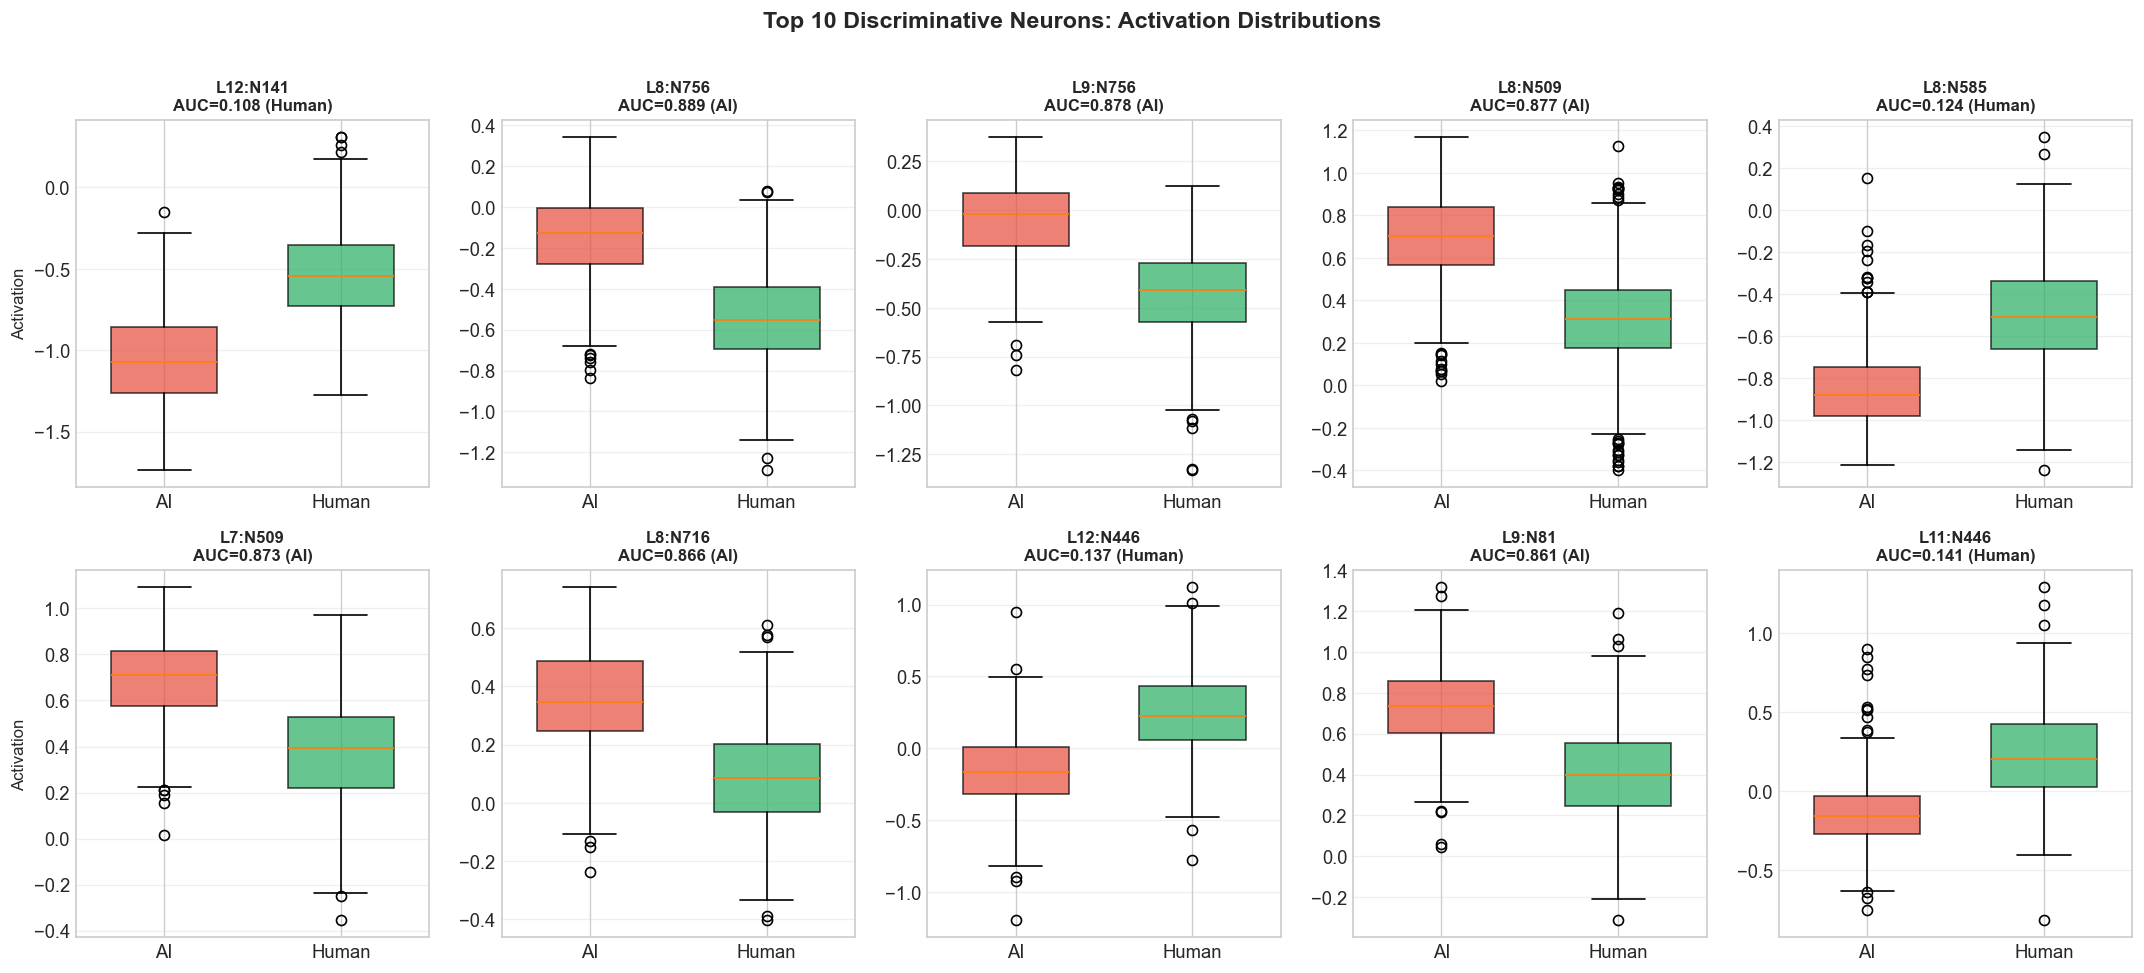

Saved: ..\results\figures\figure2_activation_boxplots.png


In [28]:
# Figure 2: Top-10 Neuron Activation Boxplots
top10 = disc_df.nlargest(10, 'auc_deviation')

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, (_, neuron) in enumerate(top10.iterrows()):
    layer = int(neuron['layer'])
    neuron_idx = int(neuron['neuron_idx'])
    auc = neuron['auc']
    
    layer_acts = np.load(RESULTS_PATH / f'layer_{layer}_activations.npy')
    neuron_acts = layer_acts[:, neuron_idx]
    
    ax = axes[idx]
    bp = ax.boxplot([neuron_acts[ai_mask], neuron_acts[human_mask]],
                     tick_labels=['AI', 'Human'], patch_artist=True, widths=0.6)
    
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#27ae60')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_alpha(0.7)
    
    pref = 'AI' if auc > 0.5 else 'Human'
    ax.set_title(f'L{layer}:N{neuron_idx}\nAUC={auc:.3f} ({pref})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Activation' if idx % 5 == 0 else '', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Top 10 Discriminative Neurons: Activation Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure2_activation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure2_activation_boxplots.png"}')

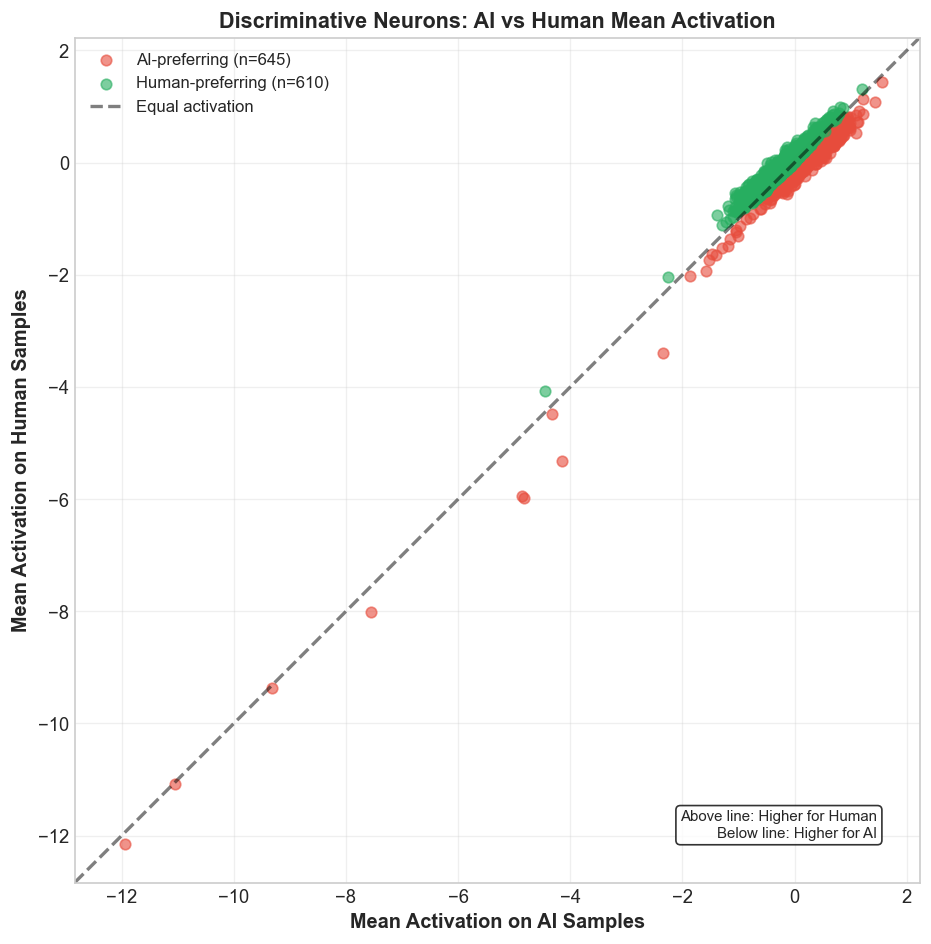

Saved: ..\results\figures\figure3_activation_scatter.png


In [29]:
# Figure 3: Mean Activation Scatter
fig, ax = plt.subplots(figsize=(8, 8))

ai_pref_mask = disc_df['auc'] > AUC_THRESHOLD_HIGH
human_pref_mask = disc_df['auc'] < AUC_THRESHOLD_LOW

ax.scatter(disc_df.loc[ai_pref_mask, 'ai_median'],
           disc_df.loc[ai_pref_mask, 'human_median'],
           c='#e74c3c', alpha=0.6, s=40, label=f'AI-preferring (n={ai_pref_mask.sum()})')
ax.scatter(disc_df.loc[human_pref_mask, 'ai_median'],
           disc_df.loc[human_pref_mask, 'human_median'],
           c='#27ae60', alpha=0.6, s=40, label=f'Human-preferring (n={human_pref_mask.sum()})')

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Equal activation')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel('Mean Activation on AI Samples', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Activation on Human Samples', fontsize=12, fontweight='bold')
ax.set_title('Discriminative Neurons: AI vs Human Mean Activation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

ax.text(0.95, 0.05, 'Above line: Higher for Human\nBelow line: Higher for AI',
        transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'figure3_activation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIGURES_PATH / "figure3_activation_scatter.png"}')

# Section C: Statistical Validation

In [30]:
# === STATISTICAL VALIDATION ===
# Compute all validation metrics

# 1. Multiple testing correction (using ALPHA constant)
n_tests = len(neurons_df)
bonferroni_alpha = ALPHA / n_tests
n_survive = (disc_df['p_value'] < bonferroni_alpha).sum()
survive_pct = n_survive / len(disc_df) * 100

# 2. Effect sizes
large_d = (disc_df['cohens_d'].abs() > 0.8).sum()
large_d_pct = large_d / len(disc_df) * 100
medium_d = ((disc_df['cohens_d'].abs() > 0.5) & (disc_df['cohens_d'].abs() <= 0.8)).sum()
medium_d_pct = medium_d / len(disc_df) * 100
mean_d = disc_df['cohens_d'].abs().mean()

# 3. P-values
median_p = disc_df['p_value'].median()
max_p = disc_df['p_value'].max()

# 4. Correlation/redundancy (top 50 neurons)
top50 = disc_df.nlargest(50, 'auc_deviation')
activation_matrix = []
for _, row in top50.iterrows():
    layer = int(row['layer'])
    idx = int(row['neuron_idx'])
    acts = np.load(RESULTS_PATH / f'layer_{layer}_activations.npy')[:, idx]
    activation_matrix.append(acts)
activation_matrix = np.array(activation_matrix)
corr_matrix = np.corrcoef(activation_matrix)
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
mean_corr = np.abs(upper_tri).mean()
high_corr_pairs = (np.abs(upper_tri) > 0.7).sum()
total_pairs = len(upper_tri)
high_corr_pct = high_corr_pairs / total_pairs * 100

# Print detailed validation table
print('STATISTICAL VALIDATION TABLE')
print('━'*70)
print(f"{'Metric':<45} {'Value':>20}")
print('━'*70)
print(f"{'Multiple testing (Bonferroni)':<45} {survive_pct:.0f}% survived")
print(f"{'Large effect sizes (|d| > 0.8)':<45} {large_d_pct:.1f}%")
print(f"{'Medium effect sizes (0.5 < |d| ≤ 0.8)':<45} {medium_d_pct:.1f}%")
print(f"{'Mean |Cohens d|':<45} {mean_d:.3f}")
print('─'*70)
print(f"{'Median p-value':<45} {median_p:.2e}")
print(f"{'Maximum p-value':<45} {max_p:.2e}")
print('─'*70)
print(f"{'Mean pairwise correlation (top 50)':<45} {mean_corr:.3f}")
print(f"{'Highly correlated pairs (|r| > 0.7)':<45} {high_corr_pct:.1f}%")
print('━'*70)
print(f"\nBonferroni correction details:")
print(f"  Original α = {ALPHA}")
print(f"  Number of tests = {n_tests:,}")
print(f"  Adjusted α' = {bonferroni_alpha:.2e}")
print('━'*70)

STATISTICAL VALIDATION TABLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                                                       Value
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Multiple testing (Bonferroni)                 100% survived
Large effect sizes (|d| > 0.8)                82.9%
Medium effect sizes (0.5 < |d| ≤ 0.8)         17.1%
Mean |Cohens d|                               0.973
──────────────────────────────────────────────────────────────────────
Median p-value                                1.10e-38
Maximum p-value                               6.54e-28
──────────────────────────────────────────────────────────────────────
Mean pairwise correlation (top 50)            0.448
Highly correlated pairs (|r| > 0.7)           1.7%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Bonferroni correction details:
  Original α = 0.001
  Number of tests = 9,216
  Adjusted α' = 1.09e-07
━━━━━━━━━━━━━━━━